# Data Cleaning & EDA

Cleans the raw review dataset and explores class balance / review length before modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")

# Folder layout: datasets/raw -> datasets/processed -> datasets/final
RAW_DIR = Path("datasets/raw")
PROCESSED_DIR = Path("datasets/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
df = pd.read_csv(RAW_DIR / "data.csv")
print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded 10000 rows, 10 columns


,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny
0,9yKzy9PApeiPPOUJEtnvkg,2011-01-26,fWKvX83p0-ka4JS3dc6E5A,5,My wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0
1,ZRJwVLyzEJq1VAihDhYiow,2011-07-27,IjZ33sJrzXqU-0X6U8NwyA,5,I have no idea why some people give bad review...,review,0a2KyEL0d3Yb1V6aivbIuQ,0,0,0
2,6oRAC4uyJCsJl1X0WZpVSA,2012-06-14,IESLBzqUCLdSzSqm0eCSxQ,4,love the gyro plate. Rice is so good and I als...,review,0hT2KtfLiobPvh6cDC8JQg,0,1,0
3,_1QQZuf4zZOyFCvXc0o6Vg,2010-05-27,G-WvGaISbqqaMHlNnByodA,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",review,uZetl9T0NcROGOyFfughhg,1,2,0
4,6ozycU1RpktNG2-1BroVtw,2012-01-05,1uJFq2r5QfJG_6ExMRCaGw,5,General Manager Scott Petello is a good egg!!!...,review,vYmM4KTsC8ZfQBg-j5MWkw,0,0,0


In [3]:
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   business_id  10000 non-null  object
 1   date         10000 non-null  object
 2   review_id    10000 non-null  object
 3   stars        10000 non-null  int64 
 4   text         10000 non-null  object
 5   type         10000 non-null  object
 6   user_id      10000 non-null  object
 7   cool         10000 non-null  int64 
 8   useful       10000 non-null  int64 
 9   funny        10000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 781.4+ KB


,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny
count,10000,10000,10000,10000.000000,10000,10000,10000,10000.000000,10000.000000,10000.000000
unique,4174,1995,10000,NaN,9998,1,6403,NaN,NaN,NaN
top,JokKtdXU7zXHcr20Lrk29A,2011-03-28,fWKvX83p0-ka4JS3dc6E5A,NaN,Great service,review,fczQCSmaWF78toLEmb0Zsw,NaN,NaN,NaN
freq,37,21,1,NaN,2,10000,38,NaN,NaN,NaN
mean,NaN,NaN,NaN,3.777500,NaN,NaN,NaN,0.876800,1.409300,0.701300
std,NaN,NaN,NaN,1.214636,NaN,NaN,NaN,2.067861,2.336647,1.907942
min,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000
50%,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,0.000000,1.000000,0.000000
75%,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,1.000000,2.000000,1.000000


In [4]:
# Missing values and duplicates
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

business_id    0
date           0
review_id      0
stars          0
text           0
type           0
user_id        0
cool           0
useful         0
funny          0
dtype: int64
Duplicate rows: 0


In [5]:
# Keep only what we need and give the text column a clearer name
df = df[["text", "stars"]].rename(columns={"text": "review"})
df["stars"].value_counts().sort_index()

stars
1     749
2     927
3    1461
4    3526
5    3337
Name: count, dtype: int64

In [6]:
# Turn the 1-5 star rating into a 3-class sentiment label
def to_sentiment(stars):
    if stars <= 2:
        return "Negative"
    elif stars == 3:
        return "Neutral"
    return "Positive"

df["sentiment"] = df["stars"].apply(to_sentiment)
df["sentiment"].value_counts()

sentiment
Positive    6863
Negative    1676
Neutral     1461
Name: count, dtype: int64

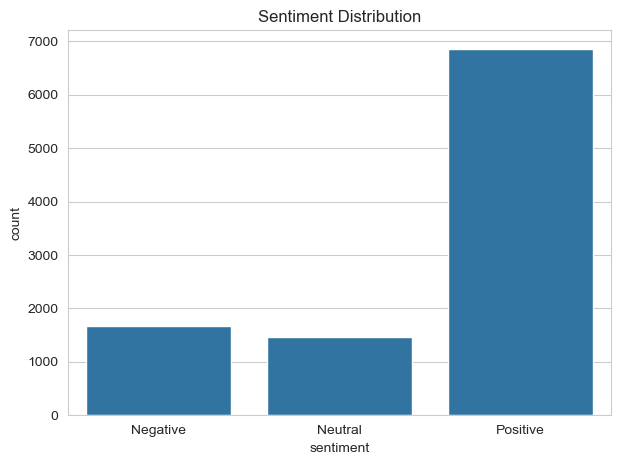

sentiment
Positive    68.63
Negative    16.76
Neutral     14.61
Name: proportion, dtype: float64

In [7]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="sentiment", order=["Negative", "Neutral", "Positive"])
plt.title("Sentiment Distribution")
plt.show()

(df["sentiment"].value_counts(normalize=True) * 100).round(2)

In [8]:
# Basic text-length features
df["review_length"] = df["review"].str.len()
df["word_count"] = df["review"].str.split().str.len()
df[["review_length", "word_count"]].describe()

,review_length,word_count
count,10000.000000,10000.000000
mean,710.738700,131.039600
std,617.399827,113.584114
min,1.000000,1.000000
25%,294.000000,54.000000
50%,541.500000,101.000000
75%,930.000000,173.000000
max,4997.000000,945.000000


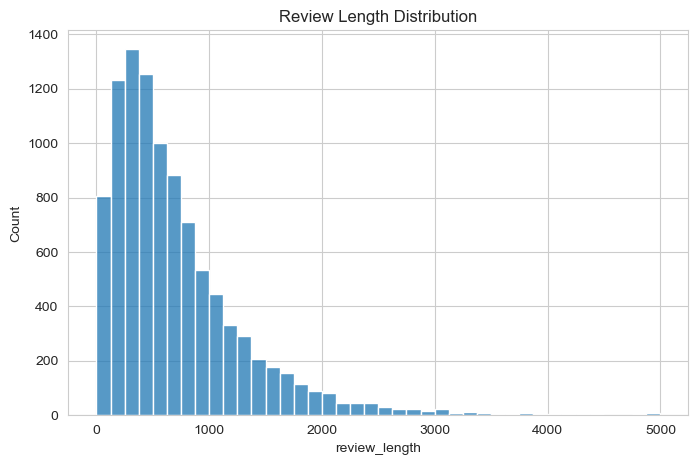

sentiment
Negative    835.221957
Neutral     758.498289
Positive    670.171791
Name: review_length, dtype: float64

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(df["review_length"], bins=40)
plt.title("Review Length Distribution")
plt.show()

df.groupby("sentiment")["review_length"].mean()

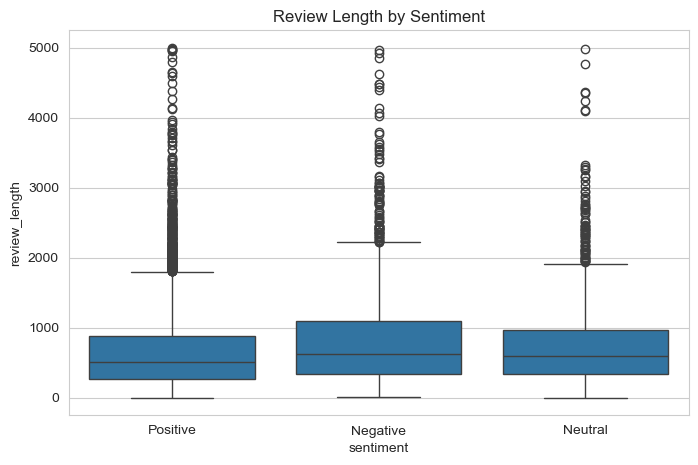

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="sentiment", y="review_length")
plt.title("Review Length by Sentiment")
plt.show()

In [11]:
# Quick sanity checks: longest/shortest review and a random sample
print("Longest review:\n", df.loc[df["review_length"].idxmax(), "review"])
print("\nShortest review:\n", df.loc[df["review_length"].idxmin(), "review"])
df.sample(10)

Longest review:
 In our continuing quest to identify cool, locally owned places to eat and/or drink, Caroline and I auditioned Vintage 95 last night. 

Before I go further, understand that whenever I go out for eats or drinks, I have  in  mind a Platonic Ideal of the Bar/Pub/Eatery I most want to frequent. I'm on a constant quest to find that  Ideal expressed in Real Life. 

Vintage 95 isn't quite there, but it's damn close. If I ever give something Five Stars, you'll know it has pegged my Platonic Ideal. Anyway...

The plan last night was for drinks. No plans for food, just Adult Beverages and warm conversation. But it turned into more.

The location in downtown Chandler is terrific for us. The owners have created a very fine visual experience - leather, stone, dark woods, good lighting. And they don't have the music turned up so loud that you CANNOT HAVE A CONVERSATION. This is one of my pet peeves. If I want to stare at people move their mouths while enduring an aural assault, I'll 

,review,stars,sentiment,review_length,word_count
254,Our server Gary was awesome. Food was amazing....,5,Positive,62,9
5309,In spite of being on the corner of 44th and Ca...,4,Positive,533,93
3219,I am only reviewing it with 2 stars because my...,2,Negative,992,187
2997,If there was a Cantina Laredo in my home (Los ...,5,Positive,1119,185
5114,Bookmans is Great! They probably don't need a...,5,Positive,551,98
4066,These are simply the BEST sandwiches and salad...,5,Positive,833,164
8103,I love this place! People are very friendly an...,5,Positive,345,67
4380,just another big store with everything everywh...,3,Neutral,50,7
4131,I feel like such a noob. We consider ourselves...,4,Positive,1844,335
3821,"Great food, bad service. Does anyone speak eng...",3,Neutral,59,10


In [12]:
clean_file = PROCESSED_DIR / "clean_reviews.csv"
df.to_csv(clean_file, index=False)
print(f"Saved cleaned dataset to {clean_file} ({df.shape[0]} rows)")

Saved cleaned dataset to datasets\processed\clean_reviews.csv (10000 rows)
